# Week 4 Day 5: Mini Machine Learning Project

Complete an end-to-end ML classification project from data loading to evaluation.

--- Mini ML Project Evaluation ---
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      0.93      0.96        14
     class_2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



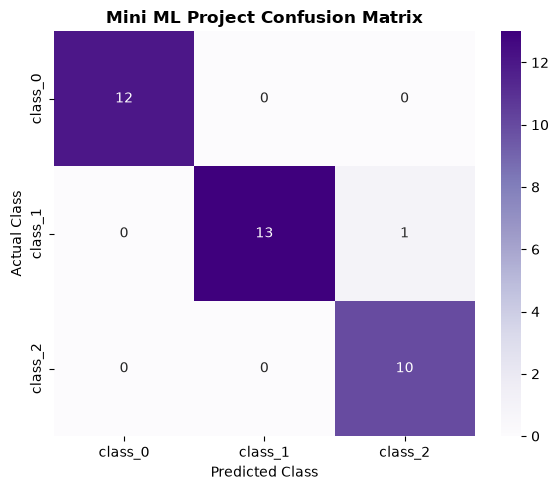

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 1. Load Data
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

# 2. Preprocess & Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train Model
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)

# 4. Evaluate
y_pred = model.predict(X_test_scaled)

print("--- Mini ML Project Evaluation ---")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=wine.target_names,
    yticklabels=wine.target_names,
)
plt.title("Mini ML Project Confusion Matrix", fontweight="bold")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
os.makedirs("saved_charts", exist_ok=True)
plt.savefig("saved_charts/Day5_MiniMLProject_CM.png", dpi=300)
plt.show()